# Process and save CS calculated using the results of CMIP6.


In [1]:
import numpy as np
np.float_ = np.float64
import glob
import os
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import nc_time_axis
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import xesmf as xe
import cartopy.crs as ccrs
import cftime
import gc
from datetime import datetime
gc.collect()
maskls=xr.open_mfdataset('/home/estefania/cmip6stop/land_sea_masks/landsea.nc')
maskl=maskls.LSMASK.where(maskls.LSMASK!=0)==1; maskl=maskl.where(maskl==1)

#### Libraries

In [2]:
from data_compilation import *
from figures_functions import *

### Read data

In [3]:
nep,gpp,ra,rh=get_nepCMIP6("1850-01","2014-12") # [kgC m-2 yr-1]
nbp=get_nbpCMIP6("1850-01","2014-12")

# weight of each model.
wm_nep=xr.open_dataset('/home/data/ResultsCS/Weights/nepCMIP6_ob_FLUXCOM-X.nc')
wm_nbp=xr.open_dataset('/home/data/ResultsCS/Weights/nbpCMIP6_ob_CarboScope.nc')

/home/estefania/anaconda3/envs/xesmf_env/lib/python3.12/site-packages/xarray/conventions.py:284: SerializationWarning: variable 'nbp' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/estefania/anaconda3/envs/xesmf_env/lib/python3.12/site-packages/xarray/conventions.py:284: SerializationWarning: variable 'nbp' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/estefania/anaconda3/envs/xesmf_env/lib/python3.12/site-packages/xarray/conventions.py:284: SerializationWarning: variable 'nbp' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/estefania/anaconda3/envs/xesmf_env/lib/python3.12/site-packages/xarray/conventions.py:284: SerializationWarning: variable 'nbp' has multiple fill values {np.float32(1e+20), np.fl

In [4]:
nep["time"]=nep["time"].astype("datetime64[ns]")
gpp["time"]=gpp["time"].astype("datetime64[ns]")
ra["time"]=ra["time"].astype("datetime64[ns]")
rh["time"]=rh["time"].astype("datetime64[ns]")
nbp["time"]=nbp["time"].astype("datetime64[ns]")

#### Save data of GPP, ra, rh, nbp for latitudinal zones accumulations

In [10]:
titles=['Global','Tropics','Mid_latitudes','High_latitudes']
tit=['glob','trop','mid','high']
varname=['gpp','ra','rh','nep','nbp']

for i in range(1):
    print(varname[i])
#for i in range(1):
    if i==0:var=gpp
    if i==1:var=ra
    if i==2:var=rh   
    if i==3:var=nep
    if i==4:var=nbp
    if i==4:var_w=var*wm_nbp; b=wm_nbp**2 # calculate ensemble.
    else:var_w=var*wm_nep; b=wm_nep**2
    # sd=(var.to_array(dim='new').std('new')*maskl)*np.sqrt(b.to_array(dim='new').sum('new')*maskl)
    mean=var_w.to_array(dim='new').sum('new')*maskl; var=var.assign(mmean=mean)
    
    for k in range(len(titles)):
        gc.collect()
    #for k in range(1,2):
        if k==0:varx=var # Global
        if k==1:mask=((var.lat <= 22.5)&(var.lat >= -22.5)) # Tropics
        if k==2:
            mask1=(var.lat > 22.5)&(var.lat < 55.0) # mid latitudes.
            mask2=(var.lat < -22.5) # mid latitudes.
        if k==3:mask=(var.lat >= 55.0) # high latitudes
        if k!=0:varx=var.where(mask,drop=True)
        if k==2:
            varx1=var.where(mask1,drop=True);varx2=var.where(mask2,drop=True)
            varxy=calc_spatial_integral(varx1)+calc_spatial_integral(varx2) 
        else:varxy=calc_spatial_integral(varx)
       varxy.to_netcdf('/home/data/ResultsCS/variables_latzones/CMIP6_'+varname[i]+'_'+titles[k]+'.nc')
      

gpp


### Only the period common with other products

In [11]:
d1='2001-01'; d2='2014-12'
nep=nep.sel(time=slice(d1,d2))
nbp=nbp.sel(time=slice(d1,d2))

#### Means

In [7]:
nep_mean=nep.mean("time")
gpp_mean=gpp.mean("time")
ra_mean=ra.mean("time")
rh_mean=rh.mean("time")
nbp_mean=nbp.mean("time")

In [5]:
# Mirar i=2, no es r1i1p1f1 y no hay gn sino gr
# i=4, no es r1i1p1f1
# i=6, no esm-hist
# i=8, no gn sino gr1


# Negative values
# i=1 # without mask
# i=3 negative values
# i=5 negative values
# i=7 without mask
#i=8 without mask

### CS

In [13]:
Mt_nep=nep.cumulative_integrate("time",datetime_unit='D')/30.4/12 # mass [kg C m-2]
Mt_nep.NCC[1:]=nep.NCC[1:].cumulative_integrate("time",datetime_unit='D')/30.4/12
cs_nep=Mt_nep.integrate("time",datetime_unit='D')/30.4/12 # carbon sequestration [kg C m-2 yr]. 

Mt_nbp=nbp.cumulative_integrate("time",datetime_unit='D')/30.4/12 # mass [kg C m-2]
Mt_nbp.NCC[1:]=nbp.NCC[1:].cumulative_integrate("time",datetime_unit='D')/30.4/12
cs_nbp=Mt_nbp.integrate("time",datetime_unit='D')/30.4/12 # carbon sequestration [kg C m-2 yr].

### Ensembles


#### Using the weight maps

In [13]:
nep_mean_w=nep_mean*wm_nep
mean=nep_mean_w.to_array(dim='new').sum('new')

In [19]:
# All data
Mtnep_w=Mt_nep*wm_nep; Mtnbp_w=Mt_nbp*wm_nbp
csnep_w=cs_nep*wm_nep; csnbp_w=cs_nbp*wm_nbp

mean=Mtnep_w.to_array(dim='new').sum('new')*maskl; Mt_nep=Mt_nep.assign(mmean=mean)
mean=Mtnbp_w.to_array(dim='new').sum('new')*maskl; Mt_nbp=Mt_nbp.assign(mmean=mean)
mean=csnep_w.to_array(dim='new').sum('new')*maskl; cs_nep=cs_nep.assign(mmean=mean)
mean=csnbp_w.to_array(dim='new').sum('new')*maskl; cs_nbp=cs_nbp.assign(mmean=mean)

# Means
gpp_mean_w=gpp_mean*wm_nep; ra_mean_w=ra_mean*wm_nep; rh_mean_w=rh_mean*wm_nep
nep_mean_w=nep_mean*wm_nep; nbp_mean_w=nbp_mean*wm_nbp

mean=gpp_mean_w.to_array(dim='new').sum('new')*maskl; gpp_mean=gpp_mean.assign(mmean=mean)
mean=ra_mean_w.to_array(dim='new').sum('new')*maskl; ra_mean=ra_mean.assign(mmean=mean)
mean=rh_mean_w.to_array(dim='new').sum('new')*maskl; rh_mean=rh_mean.assign(mmean=mean)
mean=nep_mean_w.to_array(dim='new').sum('new')*maskl; nep_mean=nep_mean.assign(mmean=mean)
mean=nbp_mean_w.to_array(dim='new').sum('new')*maskl; nbp_mean=nbp_mean.assign(mmean=mean)

Mt_nep=Mt_nep.assign_attrs(units="kgC m-2",description="Carbon mass calculated with NEP from CMIP6 models.", Ensamble="The mean value was calculated with the weights of each model obtained by comparing the nep values of each model with those of FLUXCOM-X.")
Mt_nbp=Mt_nbp.assign_attrs(units="kgC m-2",description="Carbon mass calculated with NBP from CMIP6 models.", Ensamble="The mean value was calculated with the weights of each model obtained by comparing the nbp values of each model with those of CarboSope.")
cs_nep=cs_nep.assign_attrs(units="kgC m-2 yr",description="Carbon sequestration calculated with NEP from CMIP6 models.", Ensamble="The mean value was calculated with the weights of each model obtained by comparing the nep values of each model with those of FLUXCOM-X.")
cs_nbp=cs_nbp.assign_attrs(units="kgC m-2 yr",description="Carbon sequestration calculated with NBP from CMIP6 models.", Ensamble="The mean value was calculated with the weights of each model obtained by comparing the nbp values of each model with those of CarboSope.")
gpp_mean=gpp_mean.assign_attrs(units="kgC m-2 yr-1",description="GPP from CMIP6 models.", Ensamble="The mean value was calculated with the weights of each model obtained by comparing the nep values of each model with those of FLUXCOM-X.")
ra_mean=ra_mean.assign_attrs(units="kgC m-2 yr-1",description="Autotrophic respiration from CMIP6 models.", Ensamble="The mean value was calculated with the weights of each model obtained by comparing the nep values of each model with those of FLUXCOM-X.")
rh_mean=rh_mean.assign_attrs(units="kgC m-2 yr-1",description="Heterotrophic respiration from CMIP6 models.", Ensamble="The mean value was calculated with the weights of each model obtained by comparing the nep values of each model with those of FLUXCOM-X.")
nep_mean=nep_mean.assign_attrs(units="kgC m-2 yr-1",description="NEP calculated with GPP, ra and rh from CMIP6 models.", Ensamble="The mean value was calculated with the weights of each model obtained by comparing the nep values of each model with those of FLUXCOM-X.")
nbp_mean=nbp_mean.assign_attrs(units="kgC m-2 yr-1",description="NBP from CMIP6 models.", Ensamble="The mean value was calculated with the weights of each model obtained by comparing the nbp values of each model with those of CarboScope.")


In [20]:
Mt_nep.to_netcdf('/home/data/ResultsCS/MT_nep_CMIP6_w.nc')
Mt_nbp.to_netcdf('/home/data/ResultsCS/MT_nbp_CMIP6_w.nc')

cs_nep.to_netcdf('/home/data/ResultsCS/CS_nep_CMIP6_w.nc')
cs_nbp.to_netcdf('/home/data/ResultsCS/CS_nbp_CMIP6_w.nc')


Mt_nep.to_netcdf('/home/data/ResultsCS/MT_nep_CMIP6_w_2001-2014.nc')
Mt_nbp.to_netcdf('/home/data/ResultsCS/MT_nbp_CMIP6_w_2001-2014.nc')

cs_nep.to_netcdf('/home/data/ResultsCS/CS_nep_CMIP6_w_2001-2014.nc')
cs_nbp.to_netcdf('/home/data/ResultsCS/CS_nbp_CMIP6_w_2001-2014.nc')

# Means
gpp_mean.to_netcdf('/home/data/ResultsCS/gpp_mean_CMIP6_w.nc')
ra_mean.to_netcdf('/home/data/ResultsCS/ra_mean_CMIP6_w.nc')
rh_mean.to_netcdf('/home/data/ResultsCS/rh_mean_CMIP6_w.nc')
nep_mean.to_netcdf('/home/data/ResultsCS/nep_mean_CMIP6_w.nc')
nbp_mean.to_netcdf('/home/data/ResultsCS/nbp_mean_CMIP6_w.nc')

#### All models having the same weight

In [8]:
# all data
mean=gpp.to_array(dim='new').mean('new')*maskls.LSMASK; gpp=gpp.assign(mmean=mean)
mean=ra.to_array(dim='new').mean('new')*maskls.LSMASK; ra=ra.assign(mmean=mean)
mean=rh.to_array(dim='new').mean('new')*maskls.LSMASK; rh=rh.assign(mmean=mean)
mean=nep.to_array(dim='new').mean('new')*maskls.LSMASK; nep=nep.assign(mmean=mean)
mean=nbp.to_array(dim='new').mean('new')*maskls.LSMASK; nbp=nbp.assign(mmean=mean)
mean=Mt_nep.to_array(dim='new').mean('new')*maskls.LSMASK; Mt_nep=Mt_nep.assign(mmean=mean)
mean=Mt_nbp.to_array(dim='new').mean('new')*maskls.LSMASK; Mt_nbp=Mt_nbp.assign(mmean=mean)
mean=cs_nep.to_array(dim='new').mean('new')*maskls.LSMASK; cs_nep=cs_nep.assign(mmean=mean)
mean=cs_nbp.to_array(dim='new').mean('new')*maskls.LSMASK; cs_nbp=cs_nbp.assign(mmean=mean)

# means
mean=gpp_mean.to_array(dim='new').mean('new')*maskls.LSMASK; gpp_mean=gpp_mean.assign(mmean=mean)
mean=ra_mean.to_array(dim='new').mean('new')*maskls.LSMASK; ra_mean=ra_mean.assign(mmean=mean)
mean=rh_mean.to_array(dim='new').mean('new')*maskls.LSMASK; rh_mean=rh_mean.assign(mmean=mean)
mean=nep_mean.to_array(dim='new').mean('new')*maskls.LSMASK; nep_mean=nep_mean.assign(mmean=mean)
mean=nbp_mean.to_array(dim='new').mean('new')*maskls.LSMASK; nbp_mean=nbp_mean.assign(mmean=mean)

Mt_nep=Mt_nep.assign_attrs(units="kgC m-2", description="Carbon mass calculated with NEP from CMIP6 models", Ensamble="The mean value was calculated as the average of all models.")
Mt_nbp=Mt_nbp.assign_attrs(units="kgC m-2", description="Carbon mass calculated with NBP from CMIP6 models", Ensamble="The mean value was calculated as the average of all models.")
cs_nep=cs_nep.assign_attrs(units="kgC m-2 yr", description="Carbon sequestration calculated with NEP from CMIP6 models", Ensamble="The mean value was calculated as the average of all models.")
cs_nbp=cs_nbp.assign_attrs(units="kgC m-2 yr", description="Carbon sequestration calculated with NBP from CMIP6 models", Ensamble="The mean value was calculated as the average of all models.")
gpp_mean=gpp_mean.assign_attrs(units="kgC m-2 yr-1", description="GPP from CMIP6 models", Ensamble="The mean value was calculated as the average of all models.")
ra_mean=ra_mean.assign_attrs(units="kgC m-2 yr-1", description="Autotrophic respiration from CMIP6 models", Ensamble="The mean value was calculated as the average of all models.")
rh_mean=rh_mean.assign_attrs(units="kgC m-2 yr-1", description="Heterotrophic respiration from CMIP6 models", Ensamble="The mean value was calculated as the average of all models.")
nep_mean=nep_mean.assign_attrs(units="kgC m-2 yr-1", description="NEP calculated with GPP, ra and rh from CMIP6 models", Ensamble="The mean value was calculated as the average of all models.")
nbp_mean=nbp_mean.assign_attrs(units="kgC m-2 yr-1", description="NBP from CMIP6 models", Ensamble="The mean value was calculated as the average of all models.")


In [9]:
Mt_nep.to_netcdf('/home/data/ResultsCS/MT_nep_CMIP6.nc')
Mt_nbp.to_netcdf('/home/data/ResultsCS/MT_nbp_CMIP6.nc')

cs_nep.to_netcdf('/home/data/ResultsCS/CS_nep_CMIP6.nc')
cs_nbp.to_netcdf('/home/data/ResultsCS/CS_nbp_CMIP6.nc')

gpp_mean.to_netcdf('/home/data/ResultsCS/gpp_mean_CMIP6.nc')
ra_mean.to_netcdf('/home/data/ResultsCS/ra_mean_CMIP6.nc')
rh_mean.to_netcdf('/home/data/ResultsCS/rh_mean_CMIP6.nc')
nep_mean.to_netcdf('/home/data/ResultsCS/nep_mean_CMIP6.nc')
nbp_mean.to_netcdf('/home/data/ResultsCS/nbp_mean_CMIP6.nc')

### Figure correlation of NBP between CESM2 and NorESM2-LM

In [15]:
nbp2=nbp[['NCAR','NCC']]
corr=xr.corr(nbp['NCAR'],nbp['NCC'], dim="time")

corr.to_netcdf('/home/data/ResultsCS/nbp_CMIP6_CESM2_NORESM2_corr.nc')   

/home/estefania/anaconda3/envs/xesmf_env/lib/python3.12/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/estefania/anaconda3/envs/xesmf_env/lib/python3.12/site-packages/dask/core.py:133: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/estefania/anaconda3/envs/xesmf_env/lib/python3.12/site-packages/dask/core.py:133: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


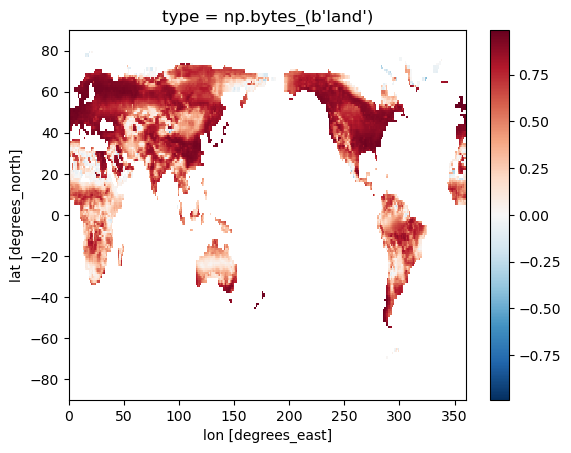

/home/estefania/anaconda3/envs/xesmf_env/lib/python3.12/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/estefania/anaconda3/envs/xesmf_env/lib/python3.12/site-packages/dask/core.py:133: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/estefania/anaconda3/envs/xesmf_env/lib/python3.12/site-packages/dask/core.py:133: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


In [14]:
corr.plot()

CS, GPP, rh and ra

#- Varney et al. 2023 Fig. 6 * CS total each model. Maybe NPP, rh, gpp
- Varney et al. 2023 Fig. 7 * CS vs NPP, CS vs. gpp, CS vs. r or Song et al. 2021 Fig. 4 or Gier et al. 2024 Fig. 15
- Varney et al. 2023 Fig. 9  GPP/NEP vs. R/NEP
#- Varney et al. 2023 Fig. 10 * time vs. CS * 
#- Gier et al. 2024 Fig. 9 Latitude vs. CS *
- Tokarska et al. 2020. Fig 1. Time aggregations.
- Ito et al. 2019. Fig 8. Accumulations of rh, ra, gpp, ne, CS.
- Loughran et al. 2023. Fig. 9. Probabilities
- Shi et al. 2024. Fig 1. Carbon change vs time, then probability distribution and box plot.
- Shi et al. 2024 Fig 3. Subplot in maps with values of NPP, rh, etc.
- Melnikova 2021. Fig 3 CS growth vs carbon uptake.


Spatial

#- Peng et al. 2021 Fig.1 Global, NH, Tropical and SH vs time. *
#- Padron 2022. Fig 6. Values CS global, Tropics, Mid latitudes, High latitudes.

Variables

- Varney et al. 2023 Fig. 7 * CS Vs Soil moisture, CS vs. T, CS vs. P or Song et al. 2021 Fig. 4 or Gier et al. 2024 Fig. 15
- Shi et al. 2024. Fig 2. by ecosystem type. *

Seasons

Firpo 2022 Fig. 11. Month, model, gain.